In [4]:
import pandas as pd
import numpy as np
JPE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Melted_Weights_applied.xlsx') 
print(JPE.shape)
JPE = JPE[['Article_ID','Weight','Affiliation','year']]
JPE = JPE.reset_index(drop=True)

QJE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/QJE_Melted_Weights_applied.xlsx') 
print(QJE.shape)
QJE = QJE[['Article_ID','Weight','Affiliation','year']]
QJE = QJE.reset_index(drop=True)

RES = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/RES_Melted_Weights_applied.xlsx') 
print(RES.shape)
RES = RES[['Article_ID','Weight','Affiliation','year']]
RES = RES.reset_index(drop=True)

AER = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/AER_Melted_Weights_applied.xlsx') 
print(AER.shape)
AER = AER[['Article_ID','Weight','Affiliation','year']]
AER = AER.reset_index(drop=True)

ECTA = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/ECTA_Melted_Weights_applied.xlsx') 
print(ECTA.shape)
ECTA = ECTA[['Article_ID','Weight','Affiliation','year']]
ECTA = ECTA.reset_index(drop=True)

(6304, 7)
(5172, 7)
(4309, 7)
(15282, 7)
(6726, 7)


In [5]:
melted = pd.concat([JPE, QJE, RES, AER, ECTA])

In [6]:
Melted_to_aggregate= melted.copy()
Melted_to_aggregate = Melted_to_aggregate[['Article_ID','year', 'Affiliation', 'Weight']]
print(Melted_to_aggregate.head())
print(Melted_to_aggregate.shape)
Melted_to_aggregate.dtypes

Melted_to_count= melted.copy()
Melted_to_sum= melted.copy()

   Article_ID  year              Affiliation  Weight
0     1825913  1940     Washington Dc (City)     1.0
1     1825908  1940    University Of Chicago     1.0
2     1824384  1940      Columbia University     1.0
3     1824382  1940       Cornell University     1.0
4     1824381  1940  University Of Edinburgh     1.0
(37793, 4)


In [15]:
Melted_to_sum = Melted_to_sum.sort_values(by='year', ascending=True)
Melted_to_sum['aff_cum_sum'] = Melted_to_sum.groupby(['Affiliation'])['Weight'].cumsum()

#Melted_to_sum = Melted_to_sum[['Article_ID' , 'Affiliation','year', 'aff_cum_sum', 'Weight']]

Melted_to_sum = Melted_to_sum[['Article_ID' , 'Weight','Affiliation','year', 'aff_cum_sum'] ]
# Checking the top 20 occurances of Universities over the 70 years
highest_vals_sum = Melted_to_sum.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_sum = highest_vals_sum.nlargest(20,'aff_cum_sum')
highest_vals_sum

Melted_to_sum.tail()
print(Melted_to_sum.head())


    Article_ID  Weight                               Affiliation  year  \
0      1825913     1.0                      Washington Dc (City)  1940   
57     1807645     1.0                   University Of Wisconsin  1940   
58     1807646     0.5                     Ohio State University  1940   
59     1807647     1.0                           Duke University  1940   
60     1807648     1.0  American Institute For Economic Research  1940   

    aff_cum_sum  
0           1.0  
57          1.0  
58          0.5  
59          1.0  
60          1.0  


(71, 5)
     Article_ID  Weight         Affiliation  year  aff_cum_sum
28      1825488     1.0  Harvard University  1940    14.500000
106         356     1.0  Harvard University  1941    28.458333
289     1803513     1.0  Harvard University  1942    42.058333
368     1811965     1.0  Harvard University  1943    47.058333
478     1818710     1.0  Harvard University  1944    53.058333
       Article_ID    Weight         Affiliation  year  aff_cum_sum
4529     25098802  0.333333  Harvard University  2006  1040.920635
6014       511995  0.500000  Harvard University  2007  1056.628968
3933      4626192  0.500000  Harvard University  2008  1082.448413
14566    25592533  0.166667  Harvard University  2009  1098.887302
6725     40928462  0.500000  Harvard University  2010  1124.587302
(71, 5)


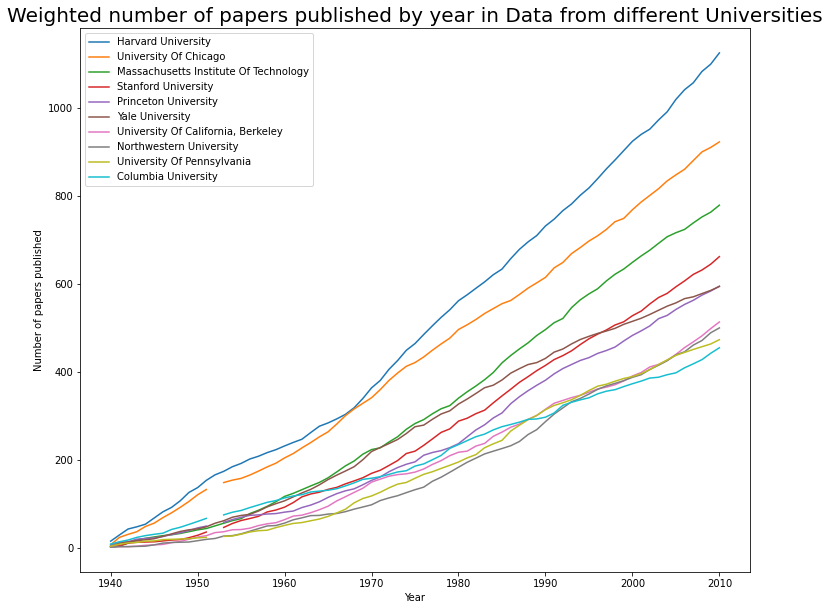

In [16]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
b = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
c = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_sum'], label = highest_vals_sum.iat[0,2])
plt.plot(b['year'],b['aff_cum_sum'], label = highest_vals_sum.iat[1,2])
plt.plot(c['year'],c['aff_cum_sum'], label = highest_vals_sum.iat[2,2])
plt.plot(d['year'],d['aff_cum_sum'], label = highest_vals_sum.iat[3,2])
plt.plot(e['year'],e['aff_cum_sum'], label = highest_vals_sum.iat[4,2])
plt.plot(f['year'],f['aff_cum_sum'], label = highest_vals_sum.iat[5,2])
plt.plot(g['year'],g['aff_cum_sum'], label = highest_vals_sum.iat[6,2])
plt.plot(h['year'],h['aff_cum_sum'], label = highest_vals_sum.iat[7,2])
plt.plot(i['year'],i['aff_cum_sum'], label = highest_vals_sum.iat[8,2])
plt.plot(j['year'],j['aff_cum_sum'], label = highest_vals_sum.iat[9,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

plt.title('Weighted number of papers published by year in Data from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Number of papers published')

plt.legend()
plt.show()